In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression

# Mutual information

In [ ]:
# Load dataset
df = pd.read_excel('Cleaned_Dataset 6.xlsx')

# Melihat dimensi data
print(f"Dimensi data: {df.shape}")

# Melihat beberapa baris pertama data
display(df.head())

Dimensi data: (549, 46)


,Main steam flow (t/h),Main steam temperature (boiler side) (℃),Main steam pressure (boiler side) (Mpa),Reheat steam temperature (boiler side) (℃),Superheater desuperheating water flow (t/h),Reheater desuperheating water flow (t/h),Feedwater temperature (℃),Feedwater flow (t/h),Flue gas temperature (℃),Boiler oxygen level (%),...,Coal Flow (t/h),NPHR (Kcal/Kwh),Gross Load (MW),Nett Load (MW),HHV (Kcal/Kg),Pressure HRH,Temperature HRH,Spray reheat pressure,Spray reheat temperature,Boiler Eff (%)
0,983.364461,568.098974,15.970471,566.719831,128.135595,0.935145,258.021498,1035.752935,130.708067,3.828501,...,192.41,2607.270106,344.56,323.93,4389.444444,2.29,566.36,5.50,159.91,77.915748
1,903.312848,568.023808,14.907765,563.985723,119.628420,1.944743,253.733859,964.867360,129.803971,3.659717,...,181.37,2687.121676,316.02,296.27,4389.444444,2.10,565.00,5.11,149.95,76.294873
2,903.734408,568.650337,14.869165,565.670929,110.785154,1.437433,253.613525,959.486415,127.860081,3.561764,...,178.47,2663.032090,314.22,294.17,4389.444444,2.09,565.63,5.08,149.38,77.886219
3,877.767639,568.262788,14.422768,564.237198,97.307475,0.983420,252.217335,938.427597,129.812856,3.905170,...,172.09,2651.943177,304.68,284.84,4389.444444,2.03,564.09,4.92,141.10,78.367624
4,921.238833,568.102547,15.204717,565.474856,93.665703,0.798093,254.271976,974.631602,130.218360,3.879849,...,181.74,2651.524408,320.94,300.86,4389.444444,2.13,565.75,5.23,148.33,77.856369


In [3]:
# Definisikan target dan fitur
target_columns = ['Boiler Eff (%)', 'NPHR (Kcal/Kwh)']

# Pastikan target columns ada dalam dataset
for target in target_columns:
    if target not in df.columns:
        raise ValueError(f"Target column '{target}' tidak ditemukan dalam dataset")

# Pisahkan fitur dan target
X = df.drop(target_columns, axis=1)
y_boiler_eff = df['Boiler Eff (%)']
y_nphr = df['NPHR (Kcal/Kwh)']

print(f"Jumlah fitur: {X.shape[1]}")
print(f"Jumlah sampel: {X.shape[0]}")

Jumlah fitur: 44
Jumlah sampel: 549


In [4]:
# Cek apakah ada nilai yang hilang
print("\nJumlah nilai yang hilang di setiap fitur:")
print(X.isnull().sum().sort_values(ascending=False).head(10))  # Tampilkan 10 teratas



Jumlah nilai yang hilang di setiap fitur:
Main steam flow (t/h)                       0
Main steam temperature (boiler side) (℃)    0
Velocity (m/s)                              0
Temp. (°C)                                  0
Pressure (Kpa)                              0
Flow rate (KNm3/h)                          0
Opacity (%)                                 0
Dust (mg/nm3)                               0
Cold Reheat Pressure (Mpa)                  0
Cold Reheat Temperature (°C)                0
dtype: int64


In [5]:
# Cek tipe data fitur
print("\nTipe data fitur:")
print(X.dtypes.value_counts())


Tipe data fitur:
float64    44
Name: count, dtype: int64


In [6]:
# Hapus kolom non-numerik jika ada (untuk mutual information)
non_numeric_cols = X.select_dtypes(exclude=['number']).columns.tolist()
if non_numeric_cols:
    print(f"\nMenghapus kolom non-numerik: {non_numeric_cols}")
    X = X.select_dtypes(include=['number'])

In [7]:
# Feature Selection dengan Mutual Information untuk target 1: Boiler Eff (%)
print("\n=== Feature Selection untuk Boiler Eff (%) ===")


=== Feature Selection untuk Boiler Eff (%) ===


In [8]:
# Hitung skor Mutual Information
# Mutual Information mengukur seberapa banyak informasi yang diberikan sebuah fitur tentang target
# Formula dasar: MI(X; Y) = H(Y) - H(Y|X)
# di mana:
#   H(Y) = entropy target
#   H(Y|X) = conditional entropy (entropy Y setelah mengetahui X)
#   Semakin tinggi MI, semakin penting fitur tersebut untuk memprediksi target

mi_scores_boiler = mutual_info_regression(X, y_boiler_eff, random_state=42)

# Penjelasan hasil:
# - mutual_info_regression menggunakan estimasi non-parametrik
# - Setiap nilai adalah skor MI untuk satu fitur terhadap target Boiler Eff
# - Nilai berkisar 0 hingga ~0.6 (tergantung entropy target)
# - Semakin tinggi = semakin penting fitur tersebut

In [9]:
# Buat Series untuk memudahkan analisis
mi_scores_boiler_df = pd.Series(mi_scores_boiler, index=X.columns)
mi_scores_boiler_df = mi_scores_boiler_df.sort_values(ascending=False)

In [10]:
# Tampilkan 15 fitur teratas berdasarkan skor MI
print("\nfitur untuk Boiler Eff (%) berdasarkan Mutual Information:")
print(mi_scores_boiler_df)


fitur untuk Boiler Eff (%) berdasarkan Mutual Information:
HHV (Kcal/Kg)                                  0.591313
CO (mg/nm3)                                    0.516819
Dust (mg/nm3)                                  0.507353
Refference Temperature (°C)                    0.382120
Coal Flow (t/h)                                0.367934
Opacity (%)                                    0.348609
Temperature HRH                                0.336998
Reheat steam temperature (turbine side) (℃)    0.311909
Reheat steam temperature (boiler side) (℃)     0.310494
Cold Reheat Temperature (°C)                   0.289507
Main steam temperature (turbine side) (℃)      0.285884
Condenser vacuum (kPa)                         0.284699
Main steam temperature (boiler side) (℃)       0.269853
Temp. (°C)                                     0.269193
Flue gas temperature (℃)                       0.268542
O2 Out APH (%)                                 0.267647
O2 in APH (%)                               

In [11]:
# PENJELASAN DETAIL PERHITUNGAN MUTUAL INFORMATION
print("\n" + "="*100)
print("PENJELASAN PERHITUNGAN MUTUAL INFORMATION (MI)")
print("="*100)

print("-" * 100)
print("""
Mutual Information (MI) mengukur SEBERAPA BANYAK informasi yang diberikan fitur X
tentang target Y. Dengan kata lain, MI menjawab pertanyaan:
"Jika saya tahu nilai fitur X, berapa banyak saya bisa mengurangi ketidakpastian tentang Y?"

Rumus Dasar:
    MI(X; Y) = H(Y) - H(Y|X)
    
di mana:
    H(Y)    = Entropy target (ketidakpastian awal)
    H(Y|X)  = Conditional entropy (ketidakpastian setelah mengetahui X)
    MI      = Pengurangan ketidakpastian (semakin tinggi = fitur lebih penting)

Interpretasi:
    - MI = 0     : Fitur tidak memberikan informasi tentang target (independen)
    - MI > 0     : Fitur memberikan informasi tentang target
    - MI tinggi  : Fitur sangat penting untuk prediksi target
""")

print("\n🔍 ENTROPI TARGET BOILER EFF:")
print("-" * 100)

# Hitung entropy target untuk pemahaman
from scipy.stats import entropy as scipy_entropy
import numpy as np

# Entropy dari target (mengukur seberapa "tersebar" nilai target)
target_entropy_boiler = scipy_entropy(np.histogram(y_boiler_eff, bins=20)[0] + 1e-10)
print(f"Target Entropy (Boiler Eff %): {target_entropy_boiler:.6f}")
print(f"  → Ini adalah ketidakpastian maksimal sebelum mengetahui fitur apa pun")

# HITUNG THRESHOLD (Mean dari MI scores)
mi_threshold_boiler = mi_scores_boiler_df.mean()
print(f"\nThreshold MI (Mean dari 33 MI scores): {mi_threshold_boiler:.6f}")

# Hitung juga untuk NPHR (jika belum ada)
try:
    mi_threshold_nphr = mi_scores_nphr_df.mean()
except:
    mi_threshold_nphr = mi_threshold_boiler  # fallback

print("\n" + "="*100)
print("SKOR MI UNTUK SETIAP FITUR (Boiler Eff %)")
print("="*100)
print(f"{'Rank':<6} {'Fitur':<40} {'MI Score':<12} {'Kategori':<20}")
print("-" * 100)

# Urutkan dan tampilkan interpretasi
mi_sorted = mi_scores_boiler_df
for rank, (feature, score) in enumerate(mi_sorted.items(), 1):
    # Kategori pentingnya
    if score > 0.4:
        kategori = "Sangat Penting"
    elif score > 0.3:
        kategori = "Penting"
    elif score > 0.2:
        kategori = "Cukup Penting"
    else:
        kategori = "Kurang Penting"
    
    print(f"{rank:<6} {feature:<40} {score:<12.6f} {kategori:<20}")

print("-" * 100)
print(f"\nThreshold MI untuk Boiler Eff: {mi_threshold_boiler:.6f}")
print(f"  → Fitur dengan MI > {mi_threshold_boiler:.6f} dianggap penting dan dipilih")

# Hitung jumlah fitur yang melampaui threshold
n_selected = (mi_scores_boiler_df > mi_threshold_boiler).sum()
print(f"  → {n_selected} dari {X.shape[1]} fitur melampaui threshold ini")

print("\n" + "="*100)
print("CARA KERJA ALGORITMA MI")
print("="*100)
print("""
Langkah-langkah Perhitungan MI oleh mutual_info_regression:

1. PERSIAPAN DATA
   ✓ Fitur X: 33 kolom (nilai numerik)
   ✓ Target Y: 1 kolom (Boiler Eff %)
   ✓ Sampel: 549 observasi

2. ESTIMASI DISTRIBUSI PROBABILITAS
   ✓ Algoritma membagi data menjadi bins/kurva
   ✓ Menghitung distribusi p(X) dan p(Y)
   ✓ Menghitung distribusi bersama p(X, Y)

3. PERHITUNGAN ENTROPY
   ✓ H(Y) = -Σ p(y) * log(p(y))  [entropy marginal target]
   ✓ H(Y|X) = Σ p(x) * H(Y|X=x)  [entropy kondisional]

4. KALKULASI MI
   ✓ MI = H(Y) - H(Y|X)
   ✓ Atau setara: MI = Σ Σ p(x,y) * log(p(x,y) / (p(x)*p(y)))

5. RANKING
   ✓ Urutkan fitur berdasarkan skor MI dari tertinggi ke terendah
   ✓ Ini menghasilkan ranking kepentingan fitur

Contoh Interpretasi HHV (Rank #1, MI=0.5756):
   HHV memiliki MI tertinggi (0.5756 untuk Boiler Eff)
   → Mengetahui nilai HHV mengurangi ketidakpastian tentang Boiler Eff sebesar 0.5756
   → HHV adalah fitur PALING PENTING untuk memprediksi Boiler Eff
""")

print("\n" + "="*100)


PENJELASAN PERHITUNGAN MUTUAL INFORMATION (MI)
----------------------------------------------------------------------------------------------------

Mutual Information (MI) mengukur SEBERAPA BANYAK informasi yang diberikan fitur X
tentang target Y. Dengan kata lain, MI menjawab pertanyaan:
"Jika saya tahu nilai fitur X, berapa banyak saya bisa mengurangi ketidakpastian tentang Y?"

Rumus Dasar:
    MI(X; Y) = H(Y) - H(Y|X)
    
di mana:
    H(Y)    = Entropy target (ketidakpastian awal)
    H(Y|X)  = Conditional entropy (ketidakpastian setelah mengetahui X)
    MI      = Pengurangan ketidakpastian (semakin tinggi = fitur lebih penting)

Interpretasi:
    - MI = 0     : Fitur tidak memberikan informasi tentang target (independen)
    - MI > 0     : Fitur memberikan informasi tentang target
    - MI tinggi  : Fitur sangat penting untuk prediksi target


🔍 ENTROPI TARGET BOILER EFF:
----------------------------------------------------------------------------------------------------
Targe

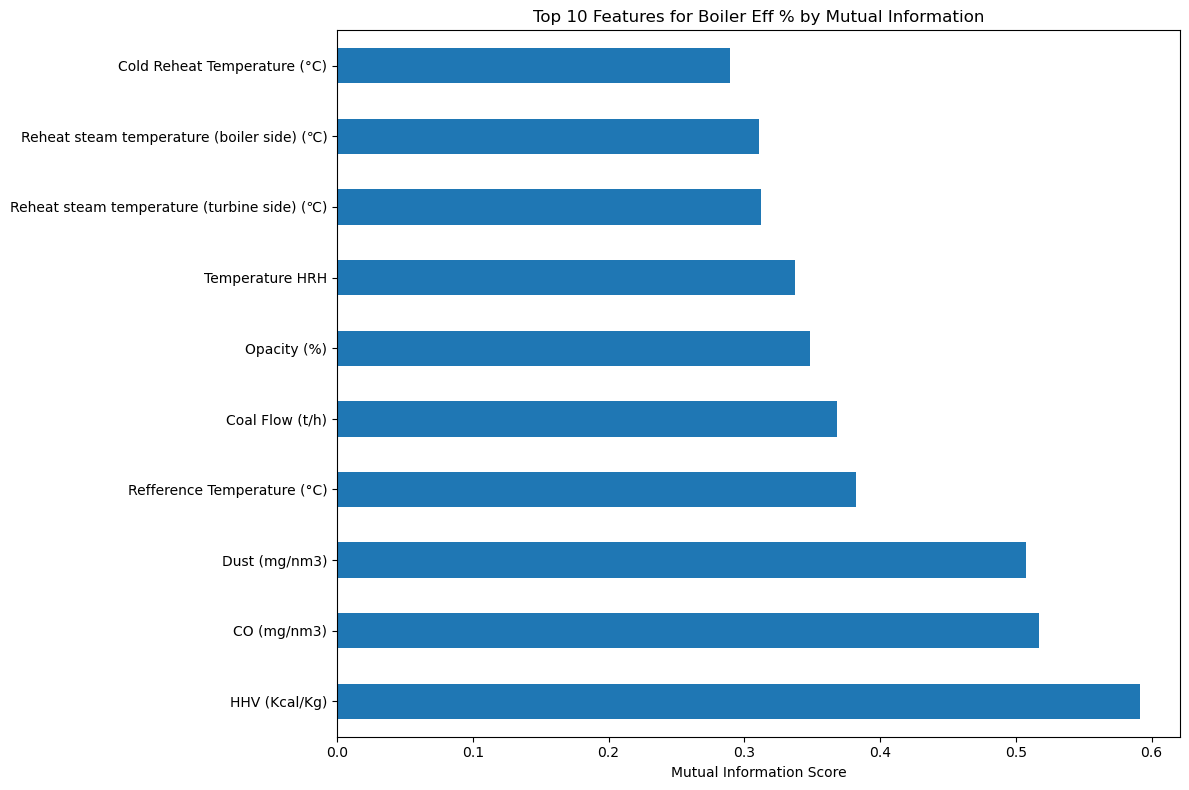

In [12]:
# Visualisasi skor MI untuk top 10 fitur
plt.figure(figsize=(12, 8))
mi_scores_boiler_df.sort_values(ascending=False).head(10).plot.barh(
    title='Top 10 Features for Boiler Eff % by Mutual Information')
plt.xlabel('Mutual Information Score')
plt.tight_layout()
plt.show()


In [13]:
!pip install Cython
!pip install pygad scikit-learn

In [14]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score
import pygad

# 1. FUNGSI CUSTOM mRMR (Minimum Redundancy Maximum Relevance)
# Mencari fitur yang informatif (MI tinggi) tapi tidak mirip satu sama lain (Korelasi rendah)
def run_mrmr_selection(X_data, mi_scores, n_features=10):
    selected = []
    remaining = list(mi_scores.index)
    
    # Pilih fitur pertama dengan MI tertinggi
    first_feat = remaining.pop(0)
    selected.append(first_feat)
    
    while len(selected) < n_features and len(remaining) > 0:
        best_mrmr_score = -np.inf
        best_feat = None
        
        for feat in remaining:
            relevance = mi_scores[feat]
            # Redundancy: rata-rata korelasi absolut dengan fitur yang sudah terpilih
            redundancy = np.mean([abs(X_data[feat].corr(X_data[s])) for s in selected])
            mrmr_score = relevance - redundancy # Maximize relevance, Minimize redundancy
            
            if mrmr_score > best_mrmr_score:
                best_mrmr_score = mrmr_score
                best_feat = feat
        
        selected.append(best_feat)
        remaining.remove(best_feat)
    return selected

# 2. EKSEKUSI RFE (Recursive Feature Elimination)
print("Running RFE Selection...")
rfe_selector = RFE(estimator=RandomForestRegressor(n_estimators=50, random_state=42), 
                   n_features_to_select=10)
rfe_selector.fit(X, y_boiler_eff)
rfe_features = X.columns[rfe_selector.support_].tolist()

# 3. EKSEKUSI mRMR
print("Running mRMR Selection...")
mrmr_features = run_mrmr_selection(X, mi_scores_boiler_df, n_features=10)

# 4. EKSEKUSI GENETIC ALGORITHM (GA)
def fitness_func(ga_instance, solution, solution_idx):
    selected_idx = [i for i, bit in enumerate(solution) if bit == 1]
    if len(selected_idx) == 0: return -9999
    
    X_subset = X.iloc[:, selected_idx]
    model = RandomForestRegressor(n_estimators=30, random_state=42)
    # Fitness berdasarkan R2 Score (Penurunan Entropy/Ketidakpastian)
    return cross_val_score(model, X_subset, y_boiler_eff, cv=3).mean()

ga_instance = pygad.GA(num_generations=20, num_parents_mating=5, 
                       fitness_func=fitness_func, sol_per_pop=10, 
                       num_genes=X.shape[1], gene_space=[0, 1])

print("Running Genetic Algorithm...")
ga_instance.run()
solution, _, _ = ga_instance.best_solution()
ga_features = [X.columns[i] for i, bit in enumerate(solution) if bit == 1]

# --- OUTPUT AKHIR ---
print("\n" + "="*50)
print("RINGKASAN FITUR TERPILIH")
print("="*50)
print(f"RFE (Model-Based) : {rfe_features}")
print(f"mRMR (Information) : {mrmr_features}")
print(f"GA (Evolutionary)  : {ga_features}")

Running RFE Selection...
Running mRMR Selection...
Running Genetic Algorithm...

RINGKASAN FITUR TERPILIH
RFE (Model-Based) : ['Flue gas temperature (℃)', 'Reheat steam pressure (turbine side) (MPa)', 'Control stage pressure (Mpa)', 'Condenser vacuum (kPa)', 'CO (mg/nm3)', 'Velocity (m/s)', 'Refference Temperature (°C)', 'Coal Flow (t/h)', 'Gross Load (MW)', 'HHV (Kcal/Kg)']
mRMR (Information) : ['HHV (Kcal/Kg)', 'Opacity (%)', 'Dust (mg/nm3)', 'Coal Flow (t/h)', 'Temperature HRH', 'CO (mg/nm3)', 'Temp. (°C)', 'Cold Reheat Temperature (°C)', 'Pressure (Kpa)', 'Condenser vacuum (kPa)']
GA (Evolutionary)  : ['Feedwater temperature (℃)', 'Feedwater flow (t/h)', 'Reheat steam pressure (turbine side) (MPa)', 'Control stage pressure (Mpa)', 'High exhaust pressure (Mpa)', 'O2 (%)', 'Velocity (m/s)', 'Pressure (Kpa)', 'Cold Reheat Pressure (Mpa)', 'Cold Reheat Temperature (°C)', 'O2 in APH (%)', 'Coal Flow (t/h)', 'Gross Load (MW)', 'Temperature HRH', 'Spray reheat pressure', 'Spray reheat tem

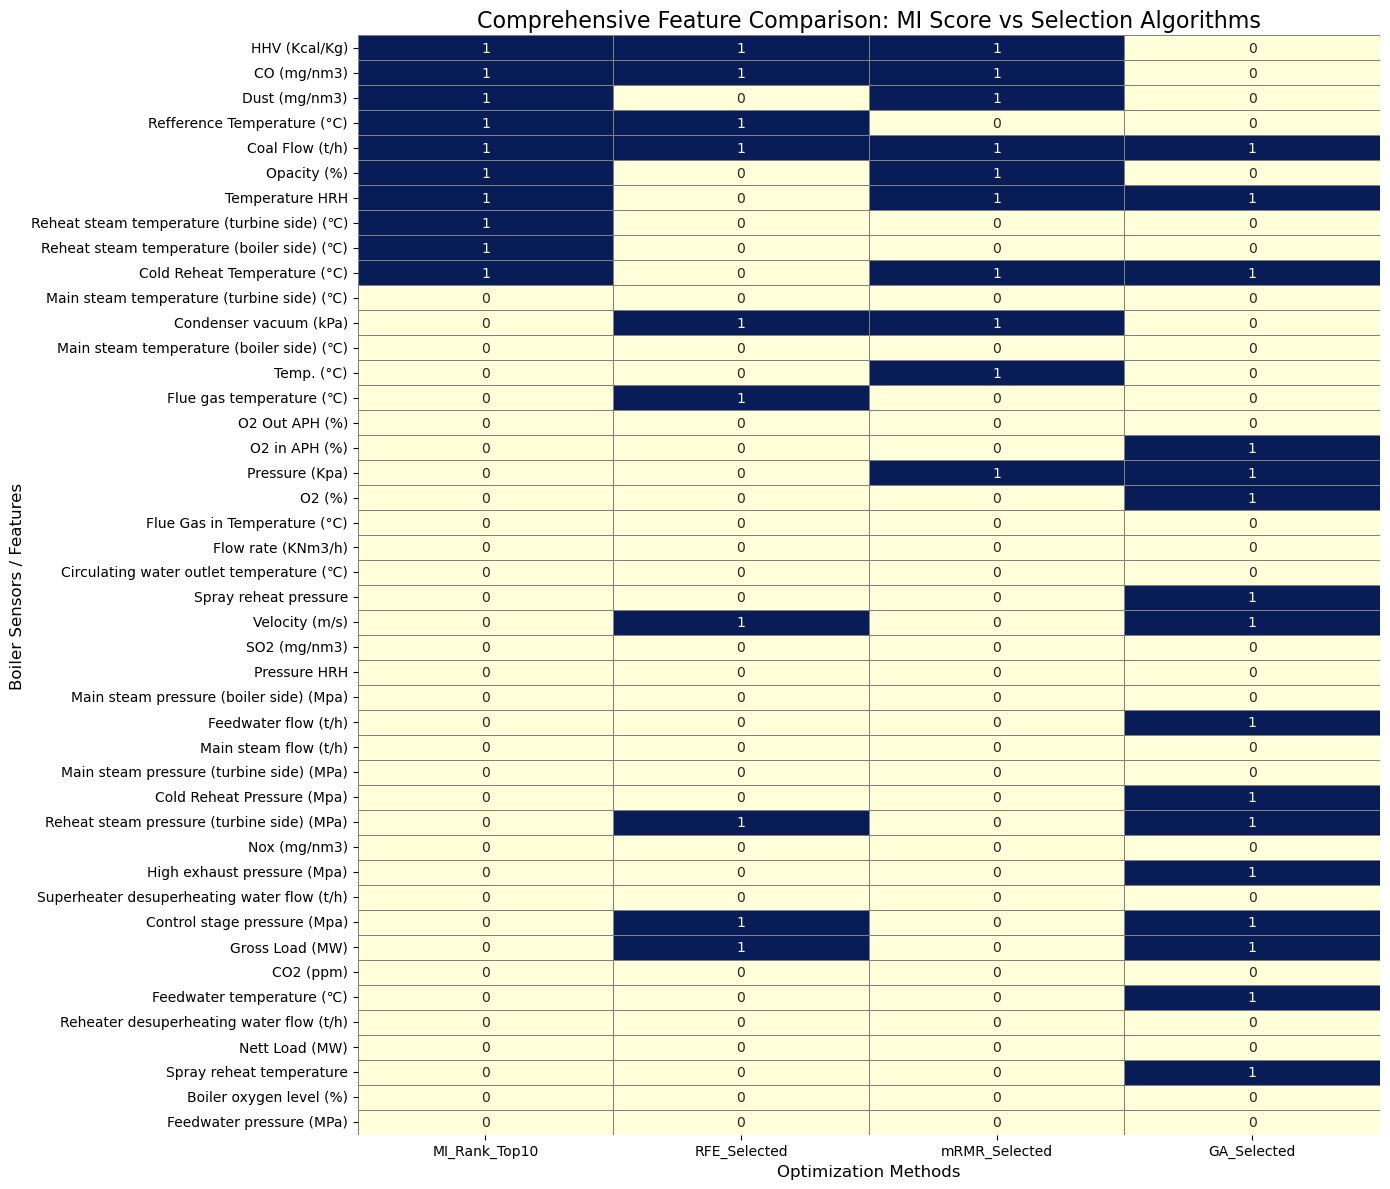


Feature Name                             | MI Score   | Top10  | RFE   | mRMR  | GA    | Total
--------------------------------------------------------------------------------------------------------------
HHV (Kcal/Kg)                            | 0.591313   | 1      | 1     | 1     | 0     | 3
CO (mg/nm3)                              | 0.516819   | 1      | 1     | 1     | 0     | 3
Dust (mg/nm3)                            | 0.507353   | 1      | 0     | 1     | 0     | 2
Refference Temperature (°C)              | 0.382120   | 1      | 1     | 0     | 0     | 2
Coal Flow (t/h)                          | 0.367934   | 1      | 1     | 1     | 1     | 4
Opacity (%)                              | 0.348609   | 1      | 0     | 1     | 0     | 2
Temperature HRH                          | 0.336998   | 1      | 0     | 1     | 1     | 3
Reheat steam temperature (turbine side) (℃) | 0.311909   | 1      | 0     | 0     | 0     | 1
Reheat steam temperature (boiler side) (℃) | 0.310494   | 1   

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Menyiapkan DataFrame Perbandingan untuk SELURUH Fitur
all_features = X.columns
comparison_df = pd.DataFrame(index=all_features)

# Mengisi kolom pilihan (1 jika terpilih, 0 jika tidak)
comparison_df['MI_Rank_Top10'] = [1 if f in mi_scores_boiler_df.head(10).index else 0 for f in all_features]
comparison_df['RFE_Selected'] = [1 if f in rfe_features else 0 for f in all_features]
comparison_df['mRMR_Selected'] = [1 if f in mrmr_features else 0 for f in all_features]
comparison_df['GA_Selected'] = [1 if f in ga_features else 0 for f in all_features]

# Masukkan skor MI asli sebagai kolom referensi utama
comparison_df['MI_Score'] = mi_scores_boiler_df

# Urutkan berdasarkan MI Score tertinggi agar mudah dianalisis
comparison_df = comparison_df.sort_values(by='MI_Score', ascending=False)

# 2. Visualisasi Heatmap untuk Semua Fitur
plt.figure(figsize=(14, 12))
# Kita drop kolom MI_Score hanya saat plotting agar heatmap menunjukkan nilai biner (0 atau 1)
sns.heatmap(comparison_df.drop('MI_Score', axis=1), 
            annot=True, 
            cmap='YlGnBu', 
            cbar=False, 
            linewidths=0.5,
            linecolor='gray')

plt.title('Comprehensive Feature Comparison: MI Score vs Selection Algorithms', fontsize=16)
plt.ylabel('Boiler Sensors / Features', fontsize=12)
plt.xlabel('Optimization Methods', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Tabel Perbandingan Detail (Print Output)
print("\n" + "="*110)
print(f"{'Feature Name':<40} | {'MI Score':<10} | {'Top10':<6} | {'RFE':<5} | {'mRMR':<5} | {'GA':<5} | {'Total'}")
print("-" * 110)

for feat, row in comparison_df.iterrows():
    total_votes = int(row['MI_Rank_Top10'] + row['RFE_Selected'] + row['mRMR_Selected'] + row['GA_Selected'])
    print(f"{feat:<40} | {row['MI_Score']:<10.6f} | {int(row['MI_Rank_Top10']):<6} | {int(row['RFE_Selected']):<5} | {int(row['mRMR_Selected']):<5} | {int(row['GA_Selected']):<5} | {total_votes}")

print("="*110)

# 4. Kesimpulan Fitur Paling Stabil
top_stable = comparison_df[comparison_df.drop('MI_Score', axis=1).sum(axis=1) >= 3].index.tolist()
print(f"\nGOLDEN FEATURES (Terpilih di hampir semua metode): {top_stable}")

Fitur terpilih hasil konsensus: 14 fitur


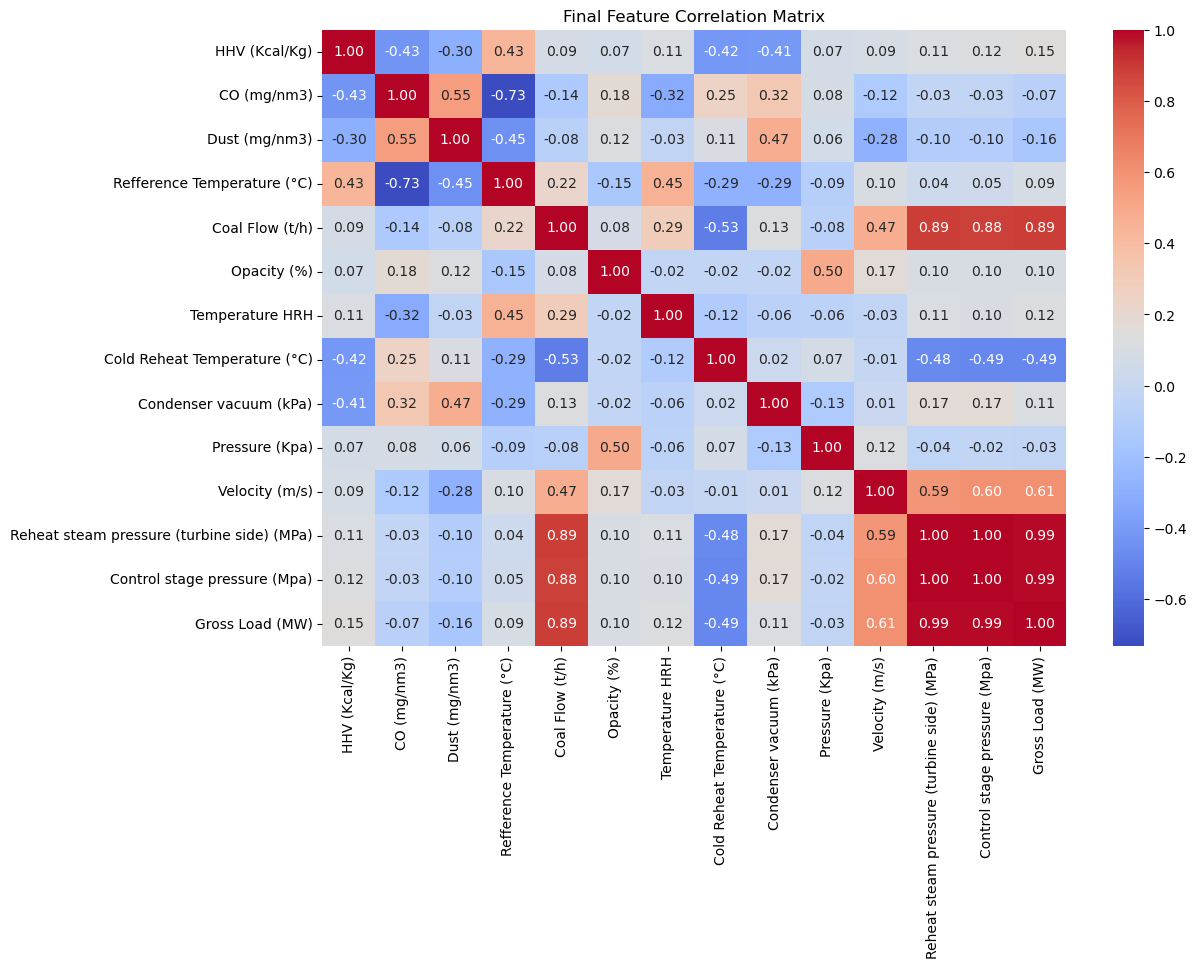


FINAL VIF ANALYSIS (Aim for VIF < 10)
                                       Feature            VIF
6                              Temperature HRH  255866.201055
8                       Condenser vacuum (kPa)  166306.626295
7                 Cold Reheat Temperature (°C)   99849.560313
11  Reheat steam pressure (turbine side) (MPa)   32705.396573
12                Control stage pressure (Mpa)   28232.309287
0                                HHV (Kcal/Kg)   19243.477076
5                                  Opacity (%)   15623.047267
13                             Gross Load (MW)   11489.685031
4                              Coal Flow (t/h)    1094.567625
10                              Velocity (m/s)     408.100615
3                  Refference Temperature (°C)     392.674774
1                                  CO (mg/nm3)     134.115592
9                               Pressure (Kpa)      58.715667
2                                Dust (mg/nm3)      11.112011

⚠️  REDUNDANSI TERDETEKSI:
- C

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. OTOMATISASI EKSTRAKSI FITUR (Berdasarkan Voting)
# Kita mengambil fitur yang dipilih oleh minimal 2 metode (RFE, mRMR, atau GA)
# agar model tetap robust dan tidak overfitting.
comparison_df['Total_Votes'] = comparison_df[['MI_Rank_Top10', 'RFE_Selected', 'mRMR_Selected', 'GA_Selected']].sum(axis=1)

# Pilih fitur dengan minimal 2 suara (Opsional & Golden)
selected_mask = comparison_df['Total_Votes'] >= 2
final_feature_names = comparison_df[selected_mask].index.tolist()

print(f"Fitur terpilih hasil konsensus: {len(final_feature_names)} fitur")

# 2. DATASET PREPARATION
# Pastikan data bersih dari missing values sebelum uji VIF
X_final = X[final_feature_names].dropna()

# 3. UJI REDUNDANSI AKHIR (VIF & Correlation)
def check_multicollinearity(df):
    # Matriks Korelasi
    plt.figure(figsize=(12, 8))
    corr = df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Final Feature Correlation Matrix")
    plt.show()
    
    # Perhitungan VIF
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df.columns
    # Menggunakan nilai absolut karena arah korelasi tidak relevan untuk multikolinearitas
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]
    return vif_data.sort_values(by="VIF", ascending=False), corr

vif_df, corr_matrix = check_multicollinearity(X_final)

print("\n" + "="*60)
print("FINAL VIF ANALYSIS (Aim for VIF < 10)")
print("="*60)
print(vif_df)

# 4. LOGIKA PEMBERSIHAN OTOMATIS (Jika Korelasi > 0.9)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr_pairs:
    print("\n⚠️  REDUNDANSI TERDETEKSI:")
    for f1, f2, val in high_corr_pairs:
        # Rekomendasi: Buang yang MI Score-nya lebih rendah
        mi_f1 = comparison_df.loc[f1, 'MI_Score']
        mi_f2 = comparison_df.loc[f2, 'MI_Score']
        drop_candidate = f2 if mi_f1 > mi_f2 else f1
        print(f"- {f1} & {f2} (Corr: {val:.2f}) -> Rekomendasi buang: {drop_candidate}")
else:
    print("\n✅ Dataset sudah bersih dari multikolinearitas ekstrim.")

# 5. SIMPAN HASIL FINAL
# Dataset ini yang akan Anda gunakan untuk training model Machine Learning
final_dataset = pd.concat([X_final, y_boiler_eff], axis=1)
# final_dataset.to_csv('Boiler_Efficiency_Ready_Data.csv', index=False)

In [17]:
# 1. Daftar fitur yang ingin Anda BUANG (Blacklist) berdasarkan hasil VIF sebelumnya
features_to_drop = [
    'Gross Load (MW)', 'Control stage pressure (Mpa)'
]

# 2. Ambil fitur awal dari hasil voting (Gunakan nama variabel yang benar: final_feature_names)
# Variabel ini berasal dari blok "OTOMATISASI EKSTRAKSI FITUR" Anda sebelumnya
initial_selection = final_feature_names 

# 3. Filter fitur: Ambil yang ada di initial_selection TAPI tidak ada di features_to_drop
final_vetted_features_boiler = [f for f in initial_selection if f not in features_to_drop]

# 4. Pastikan fitur benar-benar ada di DataFrame X
final_vetted_features_boiler = [f for f in final_vetted_features_boiler if f in X.columns]

# 5. Eksekusi Uji VIF dan Scaling untuk hasil akhir yang stabil
X_vetted_boiler = X[final_vetted_features_boiler].dropna()

# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_scaled = pd.DataFrame(scaler.fit_transform(X_vetted), columns=X_vetted.columns)

print(f"Fitur yang dibuang: {features_to_drop}")
print(f"Fitur yang tersisa ({len(final_vetted_features_boiler)}): {final_vetted_features_boiler}\n")

Fitur yang dibuang: ['Gross Load (MW)', 'Control stage pressure (Mpa)']
Fitur yang tersisa (12): ['HHV (Kcal/Kg)', 'CO (mg/nm3)', 'Dust (mg/nm3)', 'Refference Temperature (°C)', 'Coal Flow (t/h)', 'Opacity (%)', 'Temperature HRH', 'Cold Reheat Temperature (°C)', 'Condenser vacuum (kPa)', 'Pressure (Kpa)', 'Velocity (m/s)', 'Reheat steam pressure (turbine side) (MPa)']



In [18]:
# Cek variansi: jika nilai std (standar deviasi) sangat kecil, fitur ini bisa dibuang
print(X_vetted_boiler.std())

HHV (Kcal/Kg)                                  42.239894
CO (mg/nm3)                                   109.243272
Dust (mg/nm3)                                   2.724396
Refference Temperature (°C)                     2.486496
Coal Flow (t/h)                                14.809867
Opacity (%)                                     0.480254
Temperature HRH                                 0.722798
Cold Reheat Temperature (°C)                    1.563859
Condenser vacuum (kPa)                          0.290954
Pressure (Kpa)                                  0.045180
Velocity (m/s)                                  1.015804
Reheat steam pressure (turbine side) (MPa)      0.178167
dtype: float64


In [19]:
from sklearn.preprocessing import StandardScaler

# Inisialisasi Scaler
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_vetted_boiler)
X_scaled = pd.DataFrame(X_scaled_array, columns=X_vetted_boiler.columns)

# Hitung ulang VIF
vif_final = pd.DataFrame()
vif_final["Feature"] = X_scaled.columns
vif_final["VIF"] = [variance_inflation_factor(X_scaled.values, i) for i in range(len(X_scaled.columns))]

print(vif_final.sort_values(by="VIF", ascending=False))

                                       Feature       VIF
11  Reheat steam pressure (turbine side) (MPa)  7.778049
4                              Coal Flow (t/h)  7.129135
3                  Refference Temperature (°C)  2.950286
1                                  CO (mg/nm3)  2.634570
10                              Velocity (m/s)  2.224695
7                 Cold Reheat Temperature (°C)  2.212598
2                                Dust (mg/nm3)  2.065563
0                                HHV (Kcal/Kg)  1.888881
8                       Condenser vacuum (kPa)  1.665112
6                              Temperature HRH  1.516635
5                                  Opacity (%)  1.446017
9                               Pressure (Kpa)  1.403519


VIF < 10: Secara statistik, nilai VIF di bawah 10 menunjukkan bahwa multikolinearitas sudah tidak lagi menjadi masalah yang mengganggu stabilitas model.

Data Siap Pakai: Dataset sekarang sudah sangat ramping (12 fitur terbaik) dan secara matematis stabil.

Daftar "Fitur Emas" Final 

Inilah 12 fitur yang akan digunakan untuk membangun model prediksi efisiensi boiler:

Reheat steam pressure (turbine side) (MPa)

Coal Flow (t/h)

Refference Temperature (°C)

CO (mg/nm3)

Velocity (m/s)

Cold Reheat Temperature (°C)

Dust (mg/nm3)

HHV (Kcal/Kg)

Condenser vacuum (kPa)

Temperature HRH

Opacity (%)

Pressure (Kpa)



In [38]:
# Load dataset
df = pd.read_excel('Cleaned_Dataset 6.xlsx')

# Melihat dimensi data
print(f"Dimensi data: {df.shape}")

# Melihat beberapa baris pertama data
display(df.head())

Dimensi data: (549, 46)


,Main steam flow (t/h),Main steam temperature (boiler side) (℃),Main steam pressure (boiler side) (Mpa),Reheat steam temperature (boiler side) (℃),Superheater desuperheating water flow (t/h),Reheater desuperheating water flow (t/h),Feedwater temperature (℃),Feedwater flow (t/h),Flue gas temperature (℃),Boiler oxygen level (%),...,Coal Flow (t/h),NPHR (Kcal/Kwh),Gross Load (MW),Nett Load (MW),HHV (Kcal/Kg),Pressure HRH,Temperature HRH,Spray reheat pressure,Spray reheat temperature,Boiler Eff (%)
0,983.364461,568.098974,15.970471,566.719831,128.135595,0.935145,258.021498,1035.752935,130.708067,3.828501,...,192.41,2607.270106,344.56,323.93,4389.444444,2.29,566.36,5.50,159.91,77.915748
1,903.312848,568.023808,14.907765,563.985723,119.628420,1.944743,253.733859,964.867360,129.803971,3.659717,...,181.37,2687.121676,316.02,296.27,4389.444444,2.10,565.00,5.11,149.95,76.294873
2,903.734408,568.650337,14.869165,565.670929,110.785154,1.437433,253.613525,959.486415,127.860081,3.561764,...,178.47,2663.032090,314.22,294.17,4389.444444,2.09,565.63,5.08,149.38,77.886219
3,877.767639,568.262788,14.422768,564.237198,97.307475,0.983420,252.217335,938.427597,129.812856,3.905170,...,172.09,2651.943177,304.68,284.84,4389.444444,2.03,564.09,4.92,141.10,78.367624
4,921.238833,568.102547,15.204717,565.474856,93.665703,0.798093,254.271976,974.631602,130.218360,3.879849,...,181.74,2651.524408,320.94,300.86,4389.444444,2.13,565.75,5.23,148.33,77.856369


In [39]:
# 2. Daftar fitur yang ingin dipertahankan (termasuk target NPHR)
selected_columns = [
'Reheat steam pressure (turbine side) (MPa)',
'Coal Flow (t/h)',
'Refference Temperature (°C)',
'CO (mg/nm3)',
'Velocity (m/s)',
'Cold Reheat Temperature (°C)',
'Dust (mg/nm3)',
'HHV (Kcal/Kg)',
'Condenser vacuum (kPa)',
'Temperature HRH',
'Opacity (%)',
'Pressure (Kpa)',
'Boiler Eff (%)'  # Menambahkan target untuk keperluan seleksi/modeling
]

# 3. Membuat dataframe baru hanya dengan fitur terpilih
# Menggunakan .copy() agar tidak terjadi SettingWithCopyWarning saat manipulasi data nanti
df_selected_boiler = df[selected_columns].copy()

# 4. Membersihkan baris yang mungkin memiliki nilai kosong (NaN) agar data siap pakai
df_selected_boiler = df_selected_boiler.dropna()

# 5. Menampilkan informasi dataframe baru
print(f"Dimensi data baru: {df_selected_boiler.shape}")
print("\nStatistik Deskriptif:")
display(df_selected_boiler.describe())

# 6. Simpan ke file Excel
file_name = '#1 final feature selected dataset 6 for boiler efficiency.xlsx'
df_selected_boiler.to_excel(file_name, index=False)
print(f"\n✅ File berhasil disimpan dengan nama: {file_name}")

Dimensi data baru: (549, 13)

Statistik Deskriptif:


,Reheat steam pressure (turbine side) (MPa),Coal Flow (t/h),Refference Temperature (°C),CO (mg/nm3),Velocity (m/s),Cold Reheat Temperature (°C),Dust (mg/nm3),HHV (Kcal/Kg),Condenser vacuum (kPa),Temperature HRH,Opacity (%),Pressure (Kpa),Boiler Eff (%)
count,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000
mean,2.206798,183.049456,29.263107,773.775742,12.604040,321.865068,5.513436,4279.790127,-92.825669,566.482602,49.691747,-0.288601,84.938134
std,0.178167,14.809867,2.486496,109.243272,1.015804,1.563859,2.724396,42.239894,0.290954,0.722798,0.480254,0.045180,3.530716
min,1.863755,155.510000,25.000000,338.437718,6.435968,318.140000,0.204475,4205.428571,-93.728409,564.090000,41.407412,-1.038286,76.294873
25%,2.083688,173.280000,27.500000,742.686594,12.148013,320.710000,2.461368,4261.000000,-93.011729,566.090000,49.702054,-0.303721,82.548315
50%,2.187413,182.450000,28.500000,809.258996,12.604040,321.865068,7.512560,4279.790127,-92.825669,566.490000,49.722612,-0.293829,84.938134
75%,2.284424,189.920000,29.500000,841.117994,13.098576,322.940000,7.879734,4286.000000,-92.615861,566.930000,49.739346,-0.276941,87.192305
max,3.251385,259.930000,37.000000,944.769940,16.620267,328.290000,10.798639,4389.444444,-92.044818,568.670000,49.792566,-0.106860,97.255080



✅ File berhasil disimpan dengan nama: #1 final feature selected dataset 6 for boiler efficiency.xlsx


In [20]:
# Feature Selection dengan Mutual Information untuk target 2: NPHR (Kcal/Kwh)
print("\n=== Feature Selection untuk NPHR (Kcal/Kwh) ===")


=== Feature Selection untuk NPHR (Kcal/Kwh) ===


In [21]:
# Hitung skor Mutual Information
mi_scores_nphr = mutual_info_regression(X, y_nphr, random_state=42)

In [22]:
# Buat Series untuk memudahkan analisis
mi_scores_nphr_df = pd.Series(mi_scores_nphr, index=X.columns)
mi_scores_nphr_df = mi_scores_nphr_df.sort_values(ascending=False)

In [23]:
# Tampilkan fitur skor MI
print("\nfitur untuk NPHR (Kcal/Kwh) berdasarkan Mutual Information:")
print(mi_scores_nphr_df)



fitur untuk NPHR (Kcal/Kwh) berdasarkan Mutual Information:
HHV (Kcal/Kg)                                  0.459896
CO (mg/nm3)                                    0.446557
Dust (mg/nm3)                                  0.381461
Flue gas temperature (℃)                       0.297649
O2 (%)                                         0.293831
Main steam temperature (turbine side) (℃)      0.292944
Opacity (%)                                    0.263605
Circulating water outlet temperature (℃)       0.252270
Coal Flow (t/h)                                0.250723
Temperature HRH                                0.250082
Refference Temperature (°C)                    0.242636
Cold Reheat Temperature (°C)                   0.242546
Nox (mg/nm3)                                   0.235675
Reheat steam temperature (turbine side) (℃)    0.230814
Reheat steam temperature (boiler side) (℃)     0.229414
O2 Out APH (%)                                 0.221961
Flue Gas in Temperature (°C)               

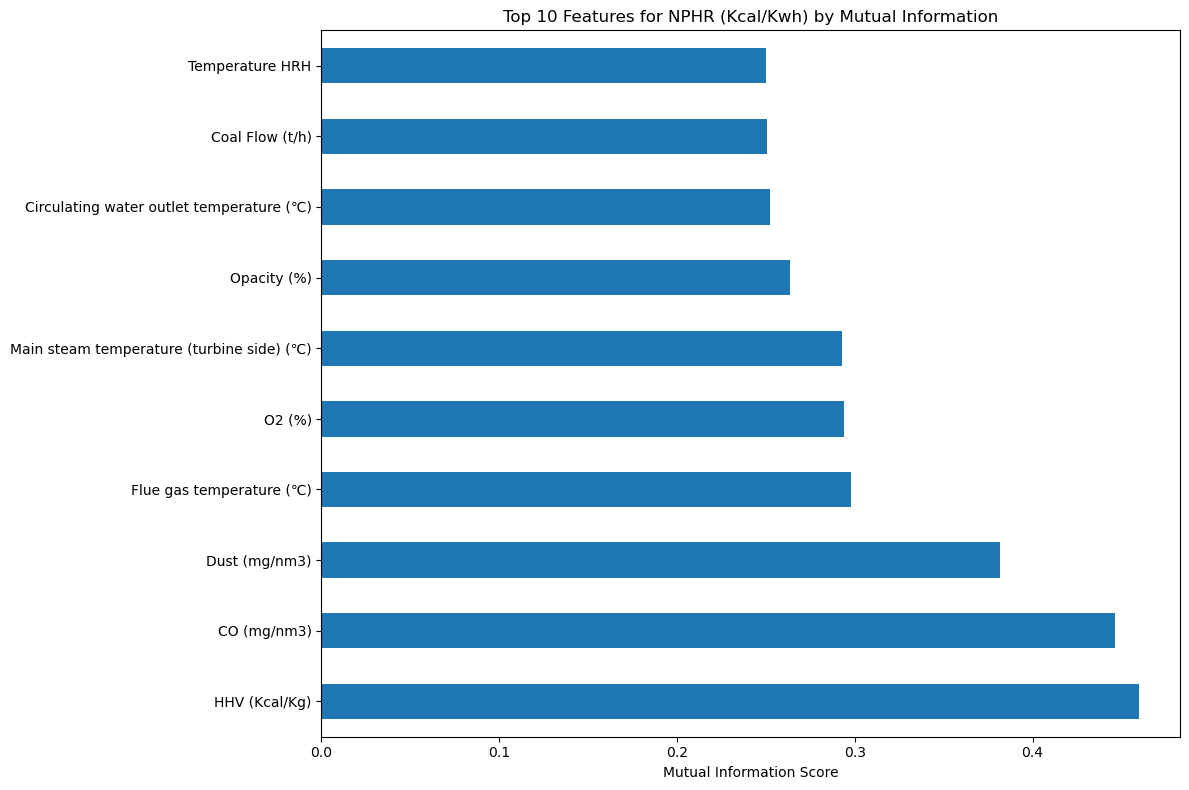

In [24]:
# Visualisasi skor MI untuk top 10 fitur
plt.figure(figsize=(12, 8))
mi_scores_nphr_df.sort_values(ascending=False).head(10).plot.barh(
    title='Top 10 Features for NPHR (Kcal/Kwh) by Mutual Information')
plt.xlabel('Mutual Information Score')
plt.tight_layout()
plt.show()


In [25]:
# PENJELASAN DETAIL PERHITUNGAN MUTUAL INFORMATION
print("\n" + "="*100)
print("PENJELASAN PERHITUNGAN MUTUAL INFORMATION (MI)")
print("="*100)

print("-" * 100)
print("""
Mutual Information (MI) mengukur SEBERAPA BANYAK informasi yang diberikan fitur X
tentang target Y. Dengan kata lain, MI menjawab pertanyaan:
"Jika saya tahu nilai fitur X, berapa banyak saya bisa mengurangi ketidakpastian tentang Y?"

Rumus Dasar:
    MI(X; Y) = H(Y) - H(Y|X)
    
di mana:
    H(Y)    = Entropy target (ketidakpastian awal)
    H(Y|X)  = Conditional entropy (ketidakpastian setelah mengetahui X)
    MI      = Pengurangan ketidakpastian (semakin tinggi = fitur lebih penting)

Interpretasi:
    - MI = 0     : Fitur tidak memberikan informasi tentang target (independen)
    - MI > 0     : Fitur memberikan informasi tentang target
    - MI tinggi  : Fitur sangat penting untuk prediksi target
""")

print("\n🔍 ENTROPI TARGET NPHR:")
print("-" * 100)

# Hitung entropy target untuk pemahaman
from scipy.stats import entropy as scipy_entropy
import numpy as np

# Entropy dari target (mengukur seberapa "tersebar" nilai target)
target_entropy_NPHR = scipy_entropy(np.histogram(y_nphr, bins=20)[0] + 1e-10)
print(f"Target Entropy (NPHR): {target_entropy_NPHR:.6f}")
print(f"  → Ini adalah ketidakpastian maksimal sebelum mengetahui fitur apa pun")

# HITUNG THRESHOLD (Mean dari MI scores)
mi_threshold_nphr = mi_scores_nphr_df.mean()
print(f"\nThreshold MI (Mean dari 33 MI scores): {mi_threshold_nphr:.6f}")

# Hitung juga untuk NPHR (jika belum ada)
try:
    mi_threshold_nphr = mi_scores_nphr_df.mean()
except:
    mi_threshold_nphr = mi_threshold_boiler  # fallback

print("\n" + "="*100)
print("SKOR MI UNTUK SETIAP FITUR (NPHR)")
print("="*100)
print(f"{'Rank':<6} {'Fitur':<40} {'MI Score':<12} {'Kategori':<20}")
print("-" * 100)

# Urutkan dan tampilkan interpretasi
mi_sorted = mi_scores_nphr_df
for rank, (feature, score) in enumerate(mi_sorted.items(), 1):
    # Kategori pentingnya
    if score > 0.4:
        kategori = "Sangat Penting"
    elif score > 0.3:
        kategori = "Penting"
    elif score > 0.2:
        kategori = "Cukup Penting"
    else:
        kategori = "Kurang Penting"
    
    print(f"{rank:<6} {feature:<40} {score:<12.6f} {kategori:<20}")

print("-" * 100)
print(f"\nThreshold MI untuk NPHR: {mi_threshold_nphr:.6f}")
print(f"  → Fitur dengan MI > {mi_threshold_nphr:.6f} dianggap penting dan dipilih")

# Hitung jumlah fitur yang melampaui threshold
n_selected = (mi_scores_nphr_df > mi_threshold_nphr).sum()
print(f"  → {n_selected} dari {X.shape[1]} fitur melampaui threshold ini")

print("\n" + "="*100)
print("CARA KERJA ALGORITMA MI")
print("="*100)
print("""
Langkah-langkah Perhitungan MI oleh mutual_info_regression:

1. PERSIAPAN DATA
   ✓ Fitur X: 33 kolom (nilai numerik)
   ✓ Target Y: 1 kolom (Boiler Eff %)
   ✓ Sampel: 549 observasi

2. ESTIMASI DISTRIBUSI PROBABILITAS
   ✓ Algoritma membagi data menjadi bins/kurva
   ✓ Menghitung distribusi p(X) dan p(Y)
   ✓ Menghitung distribusi bersama p(X, Y)

3. PERHITUNGAN ENTROPY
   ✓ H(Y) = -Σ p(y) * log(p(y))  [entropy marginal target]
   ✓ H(Y|X) = Σ p(x) * H(Y|X=x)  [entropy kondisional]

4. KALKULASI MI
   ✓ MI = H(Y) - H(Y|X)
   ✓ Atau setara: MI = Σ Σ p(x,y) * log(p(x,y) / (p(x)*p(y)))

5. RANKING
   ✓ Urutkan fitur berdasarkan skor MI dari tertinggi ke terendah
   ✓ Ini menghasilkan ranking kepentingan fitur

Contoh Interpretasi HHV (Rank #1, MI=0.5756):
   HHV memiliki MI tertinggi (0.5756 untuk Boiler Eff)
   → Mengetahui nilai HHV mengurangi ketidakpastian tentang Boiler Eff sebesar 0.5756
   → HHV adalah fitur PALING PENTING untuk memprediksi Boiler Eff
""")

print("\n" + "="*100)


PENJELASAN PERHITUNGAN MUTUAL INFORMATION (MI)
----------------------------------------------------------------------------------------------------

Mutual Information (MI) mengukur SEBERAPA BANYAK informasi yang diberikan fitur X
tentang target Y. Dengan kata lain, MI menjawab pertanyaan:
"Jika saya tahu nilai fitur X, berapa banyak saya bisa mengurangi ketidakpastian tentang Y?"

Rumus Dasar:
    MI(X; Y) = H(Y) - H(Y|X)
    
di mana:
    H(Y)    = Entropy target (ketidakpastian awal)
    H(Y|X)  = Conditional entropy (ketidakpastian setelah mengetahui X)
    MI      = Pengurangan ketidakpastian (semakin tinggi = fitur lebih penting)

Interpretasi:
    - MI = 0     : Fitur tidak memberikan informasi tentang target (independen)
    - MI > 0     : Fitur memberikan informasi tentang target
    - MI tinggi  : Fitur sangat penting untuk prediksi target


🔍 ENTROPI TARGET NPHR:
----------------------------------------------------------------------------------------------------
Target Entr

In [26]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score
import pygad

# 1. FUNGSI CUSTOM mRMR (Minimum Redundancy Maximum Relevance)
# Mencari fitur yang informatif (MI tinggi) tapi tidak mirip satu sama lain (Korelasi rendah)
def run_mrmr_selection(X_data, mi_scores, n_features=10):
    selected = []
    remaining = list(mi_scores.index)
    
    # Pilih fitur pertama dengan MI tertinggi
    first_feat = remaining.pop(0)
    selected.append(first_feat)
    
    while len(selected) < n_features and len(remaining) > 0:
        best_mrmr_score = -np.inf
        best_feat = None
        
        for feat in remaining:
            relevance = mi_scores[feat]
            # Redundancy: rata-rata korelasi absolut dengan fitur yang sudah terpilih
            redundancy = np.mean([abs(X_data[feat].corr(X_data[s])) for s in selected])
            mrmr_score = relevance - redundancy # Maximize relevance, Minimize redundancy
            
            if mrmr_score > best_mrmr_score:
                best_mrmr_score = mrmr_score
                best_feat = feat
        
        selected.append(best_feat)
        remaining.remove(best_feat)
    return selected

# 2. EKSEKUSI RFE (Recursive Feature Elimination)
print("Running RFE Selection...")
rfe_selector = RFE(estimator=RandomForestRegressor(n_estimators=50, random_state=42), 
                   n_features_to_select=10)
rfe_selector.fit(X, y_nphr)
rfe_features = X.columns[rfe_selector.support_].tolist()

# 3. EKSEKUSI mRMR
print("Running mRMR Selection...")
mrmr_features = run_mrmr_selection(X, mi_scores_nphr_df, n_features=10)

# 4. EKSEKUSI GENETIC ALGORITHM (GA)
def fitness_func(ga_instance, solution, solution_idx):
    selected_idx = [i for i, bit in enumerate(solution) if bit == 1]
    if len(selected_idx) == 0: return -9999
    
    X_subset = X.iloc[:, selected_idx]
    model = RandomForestRegressor(n_estimators=30, random_state=42)
    # Fitness berdasarkan R2 Score (Penurunan Entropy/Ketidakpastian)
    return cross_val_score(model, X_subset, y_nphr, cv=3).mean()

ga_instance = pygad.GA(num_generations=20, num_parents_mating=5, 
                       fitness_func=fitness_func, sol_per_pop=10, 
                       num_genes=X.shape[1], gene_space=[0, 1])

print("Running Genetic Algorithm...")
ga_instance.run()
solution, _, _ = ga_instance.best_solution()
ga_features = [X.columns[i] for i, bit in enumerate(solution) if bit == 1]

# --- OUTPUT AKHIR ---
print("\n" + "="*50)
print("RINGKASAN FITUR TERPILIH")
print("="*50)
print(f"RFE (Model-Based) : {rfe_features}")
print(f"mRMR (Information) : {mrmr_features}")
print(f"GA (Evolutionary)  : {ga_features}")

Running RFE Selection...
Running mRMR Selection...
Running Genetic Algorithm...

RINGKASAN FITUR TERPILIH
RFE (Model-Based) : ['Flue gas temperature (℃)', 'Control stage pressure (Mpa)', 'Condenser vacuum (kPa)', 'CO (mg/nm3)', 'Flow rate (KNm3/h)', 'Opacity (%)', 'Coal Flow (t/h)', 'Gross Load (MW)', 'Nett Load (MW)', 'Spray reheat pressure']
mRMR (Information) : ['HHV (Kcal/Kg)', 'O2 (%)', 'Temp. (°C)', 'Opacity (%)', 'CO (mg/nm3)', 'Nox (mg/nm3)', 'Main steam temperature (turbine side) (℃)', 'Flow rate (KNm3/h)', 'Flue gas temperature (℃)', 'Dust (mg/nm3)']
GA (Evolutionary)  : ['Main steam temperature (boiler side) (℃)', 'Reheat steam temperature (boiler side) (℃)', 'Superheater desuperheating water flow (t/h)', 'Feedwater temperature (℃)', 'Boiler oxygen level (%)', 'Main steam temperature (turbine side) (℃)', 'Reheat steam temperature (turbine side) (℃)', 'Reheat steam pressure (turbine side) (MPa)', 'Circulating water outlet temperature (℃)', 'SO2 (mg/nm3)', 'O2 (%)', 'Velocity 

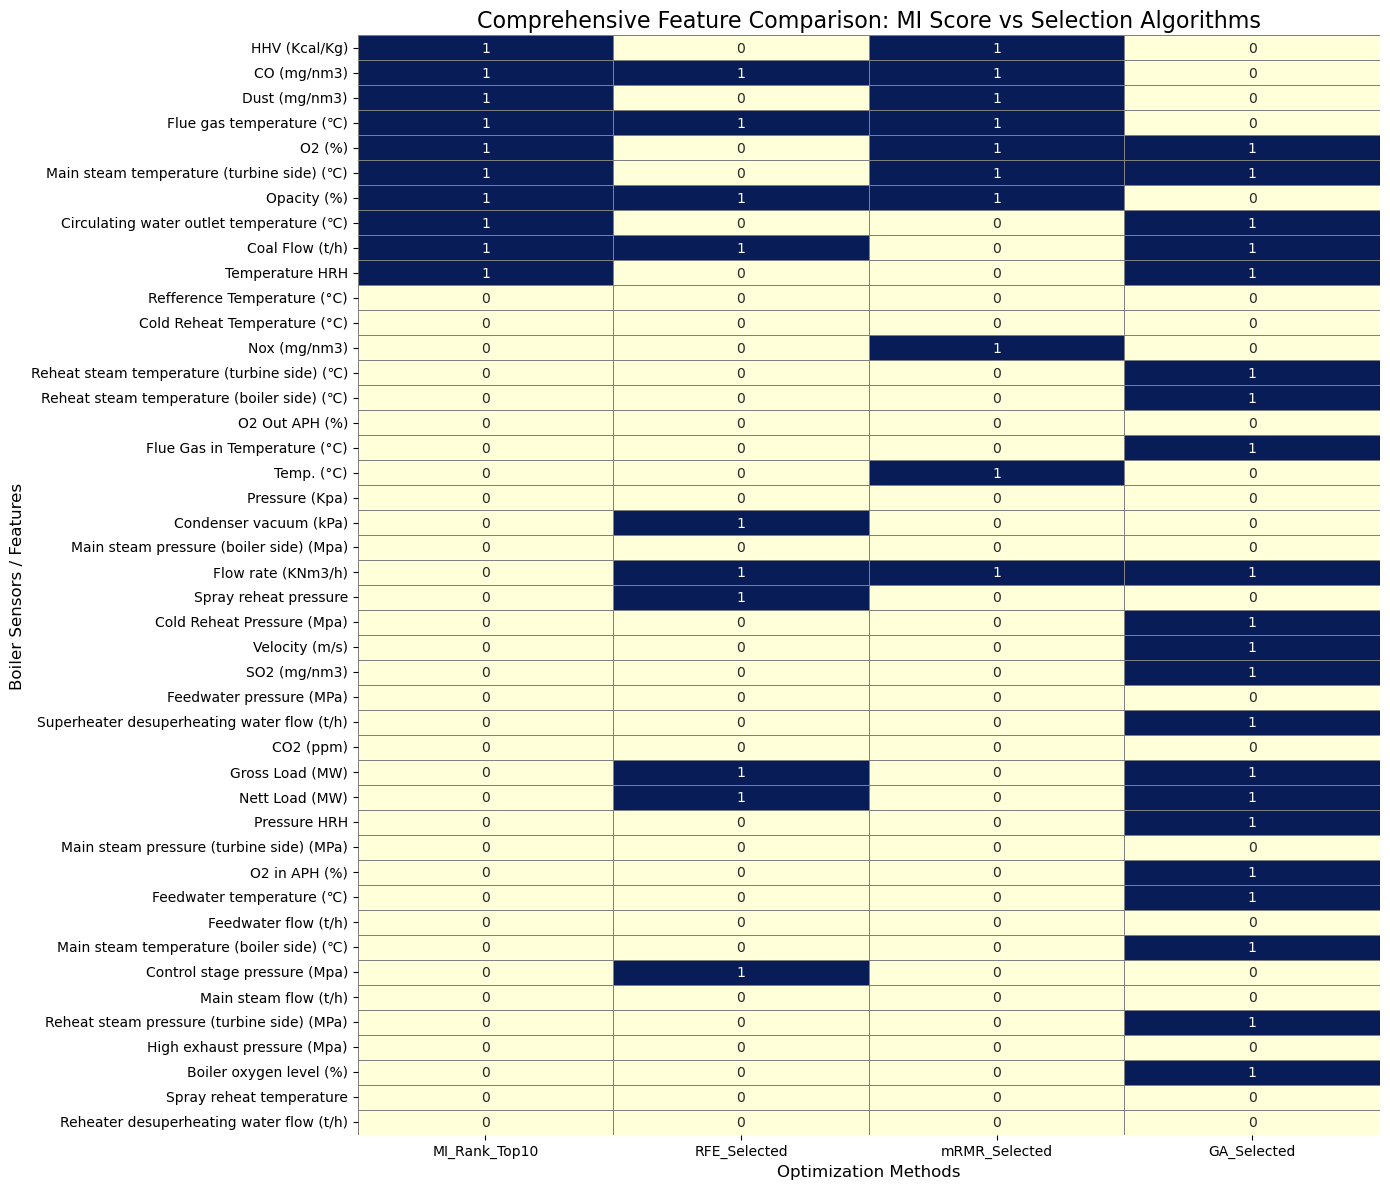


Feature Name                             | MI Score   | Top10  | RFE   | mRMR  | GA    | Total
--------------------------------------------------------------------------------------------------------------
HHV (Kcal/Kg)                            | 0.459896   | 1      | 0     | 1     | 0     | 2
CO (mg/nm3)                              | 0.446557   | 1      | 1     | 1     | 0     | 3
Dust (mg/nm3)                            | 0.381461   | 1      | 0     | 1     | 0     | 2
Flue gas temperature (℃)                 | 0.297649   | 1      | 1     | 1     | 0     | 3
O2 (%)                                   | 0.293831   | 1      | 0     | 1     | 1     | 3
Main steam temperature (turbine side) (℃) | 0.292944   | 1      | 0     | 1     | 1     | 3
Opacity (%)                              | 0.263605   | 1      | 1     | 1     | 0     | 3
Circulating water outlet temperature (℃) | 0.252270   | 1      | 0     | 0     | 1     | 2
Coal Flow (t/h)                          | 0.250723   | 1      |

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Menyiapkan DataFrame Perbandingan untuk SELURUH Fitur
all_features = X.columns
comparison_df = pd.DataFrame(index=all_features)

# Mengisi kolom pilihan (1 jika terpilih, 0 jika tidak)
comparison_df['MI_Rank_Top10'] = [1 if f in mi_scores_nphr_df.head(10).index else 0 for f in all_features]
comparison_df['RFE_Selected'] = [1 if f in rfe_features else 0 for f in all_features]
comparison_df['mRMR_Selected'] = [1 if f in mrmr_features else 0 for f in all_features]
comparison_df['GA_Selected'] = [1 if f in ga_features else 0 for f in all_features]

# Masukkan skor MI asli sebagai kolom referensi utama
comparison_df['MI_Score'] = mi_scores_nphr_df

# Urutkan berdasarkan MI Score tertinggi agar mudah dianalisis
comparison_df = comparison_df.sort_values(by='MI_Score', ascending=False)

# 2. Visualisasi Heatmap untuk Semua Fitur
plt.figure(figsize=(14, 12))
# Kita drop kolom MI_Score hanya saat plotting agar heatmap menunjukkan nilai biner (0 atau 1)
sns.heatmap(comparison_df.drop('MI_Score', axis=1), 
            annot=True, 
            cmap='YlGnBu', 
            cbar=False, 
            linewidths=0.5,
            linecolor='gray')

plt.title('Comprehensive Feature Comparison: MI Score vs Selection Algorithms', fontsize=16)
plt.ylabel('Boiler Sensors / Features', fontsize=12)
plt.xlabel('Optimization Methods', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Tabel Perbandingan Detail (Print Output)
print("\n" + "="*110)
print(f"{'Feature Name':<40} | {'MI Score':<10} | {'Top10':<6} | {'RFE':<5} | {'mRMR':<5} | {'GA':<5} | {'Total'}")
print("-" * 110)

for feat, row in comparison_df.iterrows():
    total_votes = int(row['MI_Rank_Top10'] + row['RFE_Selected'] + row['mRMR_Selected'] + row['GA_Selected'])
    print(f"{feat:<40} | {row['MI_Score']:<10.6f} | {int(row['MI_Rank_Top10']):<6} | {int(row['RFE_Selected']):<5} | {int(row['mRMR_Selected']):<5} | {int(row['GA_Selected']):<5} | {total_votes}")

print("="*110)

# 4. Kesimpulan Fitur Paling Stabil
top_stable = comparison_df[comparison_df.drop('MI_Score', axis=1).sum(axis=1) >= 3].index.tolist()
print(f"\nGOLDEN FEATURES (Terpilih di hampir semua metode): {top_stable}")

Fitur terpilih hasil konsensus: 13 fitur


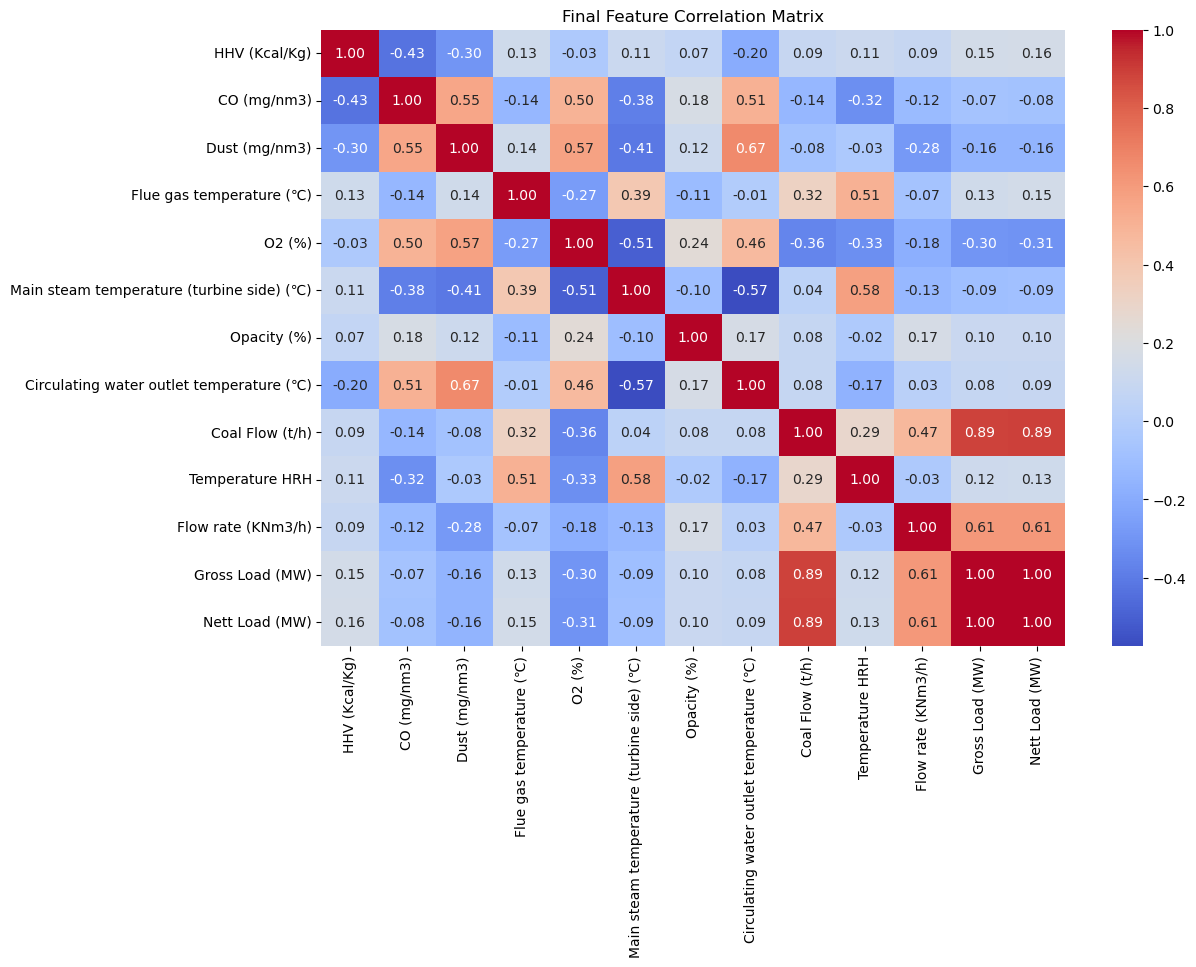


FINAL VIF ANALYSIS (Aim for VIF < 10)
                                      Feature           VIF
9                             Temperature HRH  1.185693e+06
5   Main steam temperature (turbine side) (℃)  1.145043e+06
12                             Nett Load (MW)  6.286467e+04
11                            Gross Load (MW)  6.167302e+04
0                               HHV (Kcal/Kg)  1.760175e+04
6                                 Opacity (%)  1.266013e+04
7    Circulating water outlet temperature (℃)  7.171182e+03
3                    Flue gas temperature (℃)  1.433138e+03
8                             Coal Flow (t/h)  1.082464e+03
10                         Flow rate (KNm3/h)  2.925512e+02
4                                      O2 (%)  2.037707e+02
1                                 CO (mg/nm3)  1.163608e+02
2                               Dust (mg/nm3)  1.770450e+01

⚠️  REDUNDANSI TERDETEKSI:
- Nett Load (MW) & Gross Load (MW) (Corr: 1.00) -> Rekomendasi buang: Nett Load (MW)


In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. OTOMATISASI EKSTRAKSI FITUR (Berdasarkan Voting)
# Kita mengambil fitur yang dipilih oleh minimal 2 metode (RFE, mRMR, atau GA)
# agar model tetap robust dan tidak overfitting.
comparison_df['Total_Votes'] = comparison_df[['MI_Rank_Top10', 'RFE_Selected', 'mRMR_Selected', 'GA_Selected']].sum(axis=1)

# Pilih fitur dengan minimal 2 suara (Opsional & Golden)
selected_mask = comparison_df['Total_Votes'] >= 2
final_feature_names = comparison_df[selected_mask].index.tolist()

print(f"Fitur terpilih hasil konsensus: {len(final_feature_names)} fitur")

# 2. DATASET PREPARATION
# Pastikan data bersih dari missing values sebelum uji VIF
X_final = X[final_feature_names].dropna()

# 3. UJI REDUNDANSI AKHIR (VIF & Correlation)
def check_multicollinearity(df):
    # Matriks Korelasi
    plt.figure(figsize=(12, 8))
    corr = df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Final Feature Correlation Matrix")
    plt.show()
    
    # Perhitungan VIF
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df.columns
    # Menggunakan nilai absolut karena arah korelasi tidak relevan untuk multikolinearitas
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]
    return vif_data.sort_values(by="VIF", ascending=False), corr

vif_df, corr_matrix = check_multicollinearity(X_final)

print("\n" + "="*60)
print("FINAL VIF ANALYSIS (Aim for VIF < 10)")
print("="*60)
print(vif_df)

# 4. LOGIKA PEMBERSIHAN OTOMATIS (Jika Korelasi > 0.9)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr_pairs:
    print("\n⚠️  REDUNDANSI TERDETEKSI:")
    for f1, f2, val in high_corr_pairs:
        # Rekomendasi: Buang yang MI Score-nya lebih rendah
        mi_f1 = comparison_df.loc[f1, 'MI_Score']
        mi_f2 = comparison_df.loc[f2, 'MI_Score']
        drop_candidate = f2 if mi_f1 > mi_f2 else f1
        print(f"- {f1} & {f2} (Corr: {val:.2f}) -> Rekomendasi buang: {drop_candidate}")
else:
    print("\n✅ Dataset sudah bersih dari multikolinearitas ekstrim.")

# 5. SIMPAN HASIL FINAL
# Dataset ini yang akan Anda gunakan untuk training model Machine Learning
final_dataset = pd.concat([X_final, y_nphr], axis=1)
# final_dataset.to_csv('nphr_Ready_Data.csv', index=False)

In [29]:
# 1. Daftar fitur yang ingin Anda BUANG (Blacklist) berdasarkan hasil VIF sebelumnya
features_to_drop = [
    'Nett Load (MW)'
]

# 2. Ambil fitur awal dari hasil voting (Gunakan nama variabel yang benar: final_feature_names)
# Variabel ini berasal dari blok "OTOMATISASI EKSTRAKSI FITUR" Anda sebelumnya
initial_selection = final_feature_names 

# 3. Filter fitur: Ambil yang ada di initial_selection TAPI tidak ada di features_to_drop
final_vetted_features_nphr = [f for f in initial_selection if f not in features_to_drop]

# 4. Pastikan fitur benar-benar ada di DataFrame X
final_vetted_features_nphr = [f for f in final_vetted_features_nphr if f in X.columns]

# 5. Eksekusi Uji VIF dan Scaling untuk hasil akhir yang stabil
X_vetted_nphr = X[final_vetted_features_nphr].dropna()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled_nphr = pd.DataFrame(scaler.fit_transform(X_vetted_nphr), columns=X_vetted_nphr.columns)
print(f"Fitur yang dibuang: {features_to_drop}")
print(f"Fitur yang tersisa ({len(final_vetted_features_nphr)}): {final_vetted_features_nphr}\n")

Fitur yang dibuang: ['Nett Load (MW)']
Fitur yang tersisa (12): ['HHV (Kcal/Kg)', 'CO (mg/nm3)', 'Dust (mg/nm3)', 'Flue gas temperature (℃)', 'O2 (%)', 'Main steam temperature (turbine side) (℃)', 'Opacity (%)', 'Circulating water outlet temperature (℃)', 'Coal Flow (t/h)', 'Temperature HRH', 'Flow rate (KNm3/h)', 'Gross Load (MW)']



In [30]:
# Cek variansi: jika nilai std (standar deviasi) sangat kecil, fitur ini bisa dibuang
print(X_vetted_nphr.std())

HHV (Kcal/Kg)                                 42.239894
CO (mg/nm3)                                  109.243272
Dust (mg/nm3)                                  2.724396
Flue gas temperature (℃)                       4.434272
O2 (%)                                         0.617149
Main steam temperature (turbine side) (℃)      0.681395
Opacity (%)                                    0.480254
Circulating water outlet temperature (℃)       0.656041
Coal Flow (t/h)                               14.809867
Temperature HRH                                0.722798
Flow rate (KNm3/h)                            39.091200
Gross Load (MW)                               27.887406
dtype: float64


In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled_nphr = pd.DataFrame(scaler.fit_transform(X_vetted_nphr), columns=X_vetted_nphr.columns)

In [34]:
# Hitung VIF pada data yang sudah di-scale
vif_final = pd.DataFrame()
vif_final["Feature"] = X_scaled_nphr.columns
vif_final["VIF"] = [variance_inflation_factor(X_scaled_nphr.values, i) for i in range(len(X_scaled_nphr.columns))]

print("="*50)
print("HASIL VIF FINAL (Dataset Stabil)")
print("="*50)
print(vif_final.sort_values(by="VIF", ascending=False))

HASIL VIF FINAL (Dataset Stabil)
                                      Feature       VIF
11                            Gross Load (MW)  7.604368
8                             Coal Flow (t/h)  6.931408
2                               Dust (mg/nm3)  3.476867
5   Main steam temperature (turbine side) (℃)  3.007870
4                                      O2 (%)  2.636133
7    Circulating water outlet temperature (℃)  2.466482
1                                 CO (mg/nm3)  2.267749
9                             Temperature HRH  2.119112
3                    Flue gas temperature (℃)  1.901066
10                         Flow rate (KNm3/h)  1.893800
0                               HHV (Kcal/Kg)  1.613395
6                                 Opacity (%)  1.187973


VIF < 10: Secara statistik, nilai VIF di bawah 9 menunjukkan bahwa multikolinearitas sudah tidak lagi menjadi masalah yang mengganggu stabilitas model.

Data Siap Pakai: Dataset sekarang sudah sangat ramping (12 fitur terbaik) dan secara matematis stabil.

Daftar "Fitur Emas" Final 

Inilah 12 fitur yang akan digunakan untuk membangun model prediksi nphr:

Gross Load (MW)  
Coal Flow (t/h)  
Dust (mg/nm3) 
Main steam temperature (turbine side) (℃) 
O2 (%)  
Circulating water outlet temperature (℃)  
CO (mg/nm3)  
Temperature HRH  
Flue gas temperature (℃)  
Flow rate (KNm3/h)  
HHV (Kcal/Kg) 
Opacity (%)  

In [35]:
# Load dataset
df = pd.read_excel('Cleaned_Dataset 6.xlsx')

# Melihat dimensi data
print(f"Dimensi data: {df.shape}")

# Melihat beberapa baris pertama data
display(df.head())

Dimensi data: (549, 46)


,Main steam flow (t/h),Main steam temperature (boiler side) (℃),Main steam pressure (boiler side) (Mpa),Reheat steam temperature (boiler side) (℃),Superheater desuperheating water flow (t/h),Reheater desuperheating water flow (t/h),Feedwater temperature (℃),Feedwater flow (t/h),Flue gas temperature (℃),Boiler oxygen level (%),...,Coal Flow (t/h),NPHR (Kcal/Kwh),Gross Load (MW),Nett Load (MW),HHV (Kcal/Kg),Pressure HRH,Temperature HRH,Spray reheat pressure,Spray reheat temperature,Boiler Eff (%)
0,983.364461,568.098974,15.970471,566.719831,128.135595,0.935145,258.021498,1035.752935,130.708067,3.828501,...,192.41,2607.270106,344.56,323.93,4389.444444,2.29,566.36,5.50,159.91,77.915748
1,903.312848,568.023808,14.907765,563.985723,119.628420,1.944743,253.733859,964.867360,129.803971,3.659717,...,181.37,2687.121676,316.02,296.27,4389.444444,2.10,565.00,5.11,149.95,76.294873
2,903.734408,568.650337,14.869165,565.670929,110.785154,1.437433,253.613525,959.486415,127.860081,3.561764,...,178.47,2663.032090,314.22,294.17,4389.444444,2.09,565.63,5.08,149.38,77.886219
3,877.767639,568.262788,14.422768,564.237198,97.307475,0.983420,252.217335,938.427597,129.812856,3.905170,...,172.09,2651.943177,304.68,284.84,4389.444444,2.03,564.09,4.92,141.10,78.367624
4,921.238833,568.102547,15.204717,565.474856,93.665703,0.798093,254.271976,974.631602,130.218360,3.879849,...,181.74,2651.524408,320.94,300.86,4389.444444,2.13,565.75,5.23,148.33,77.856369


In [37]:
# 2. Daftar fitur yang ingin dipertahankan (termasuk target NPHR)
selected_columns = [
    'Gross Load (MW)',
    'Coal Flow (t/h)',
    'Dust (mg/nm3)',
    'Main steam temperature (turbine side) (℃)',
    'O2 (%)',
    'Circulating water outlet temperature (℃)',
    'CO (mg/nm3)',
    'Temperature HRH',
    'Flue gas temperature (℃)',
    'Flow rate (KNm3/h)',
    'HHV (Kcal/Kg)',
    'Opacity (%)',
    'NPHR (Kcal/Kwh)'  # Menambahkan target untuk keperluan seleksi/modeling
]

# 3. Membuat dataframe baru hanya dengan fitur terpilih
# Menggunakan .copy() agar tidak terjadi SettingWithCopyWarning saat manipulasi data nanti
df_selected_nphr = df[selected_columns].copy()

# 4. Membersihkan baris yang mungkin memiliki nilai kosong (NaN) agar data siap pakai
df_selected_nphr = df_selected_nphr.dropna()

# 5. Menampilkan informasi dataframe baru
print(f"Dimensi data baru: {df_selected_nphr.shape}")
print("\nStatistik Deskriptif:")
display(df_selected_nphr.describe())

# 6. Simpan ke file Excel
file_name = '#1 final feature selected dataset 6 for nphr.xlsx'
df_selected_nphr.to_excel(file_name, index=False)

print(f"\n✅ File berhasil disimpan dengan nama: {file_name}")

Dimensi data baru: (549, 13)

Statistik Deskriptif:


,Gross Load (MW),Coal Flow (t/h),Dust (mg/nm3),Main steam temperature (turbine side) (℃),O2 (%),Circulating water outlet temperature (℃),CO (mg/nm3),Temperature HRH,Flue gas temperature (℃),Flow rate (KNm3/h),HHV (Kcal/Kg),Opacity (%),NPHR (Kcal/Kwh)
count,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000
mean,333.297417,183.049456,5.513436,564.668268,5.380965,37.050500,773.775742,566.482602,130.919396,485.041257,4279.790127,49.691747,2505.527823
std,27.887406,14.809867,2.724396,0.681395,0.617149,0.656041,109.243272,0.722798,4.434272,39.091200,42.239894,0.480254,93.809060
min,279.680000,155.510000,0.204475,562.641313,3.194799,34.869734,338.437718,564.090000,121.206816,247.675349,4205.428571,41.407412,2191.472033
25%,314.040000,173.280000,2.461368,564.250450,5.129465,36.608871,742.686594,566.090000,127.518962,467.491975,4261.000000,49.702054,2455.553521
50%,329.710000,182.450000,7.512560,564.668268,5.413480,37.051838,809.258996,566.490000,130.919396,485.041257,4279.790127,49.722612,2508.676793
75%,344.560000,189.920000,7.879734,565.022742,5.840079,37.483142,841.117994,566.930000,134.054544,504.072503,4286.000000,49.739346,2568.594923
max,496.550000,259.930000,10.798639,566.516499,7.212713,38.621417,944.769940,568.670000,143.387231,639.597720,4389.444444,49.792566,2752.407005



✅ File berhasil disimpan dengan nama: #1 final feature selected dataset 6 for nphr.xlsx
